In [9]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('times.csv', names=['Number of features', 'runtime', 'ram'])

In [10]:
data = data[:500]

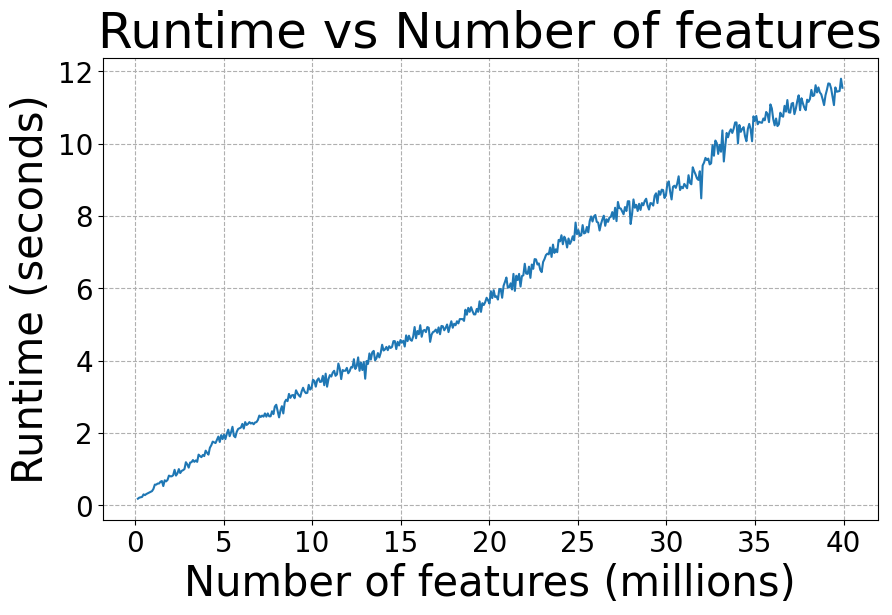

Fitted quadratic coefficients: a=0.0005416103070496352, b=0.26486832640847113, c=0.39631679799498404


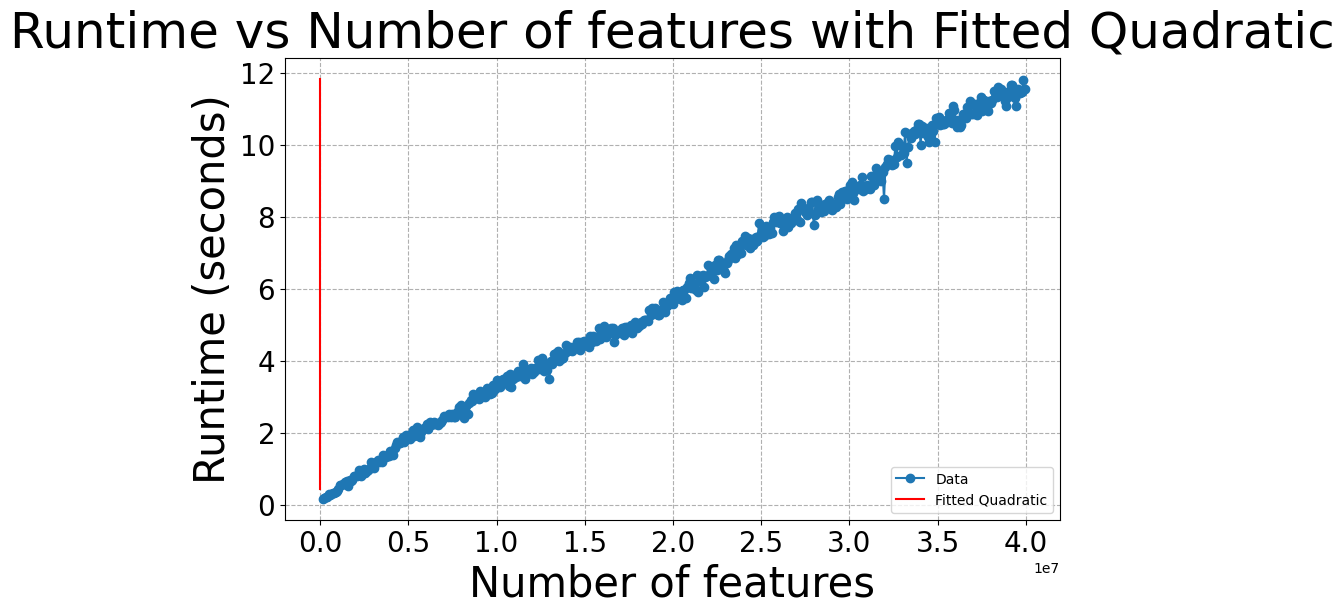

In [11]:
# Plot runtime vs size
plt.figure(figsize=(10, 6))
plt.plot(data['Number of features']/1_000_000, data['runtime'])#, marker='o')
plt.title('Runtime vs Number of features', fontsize=36)
plt.xlabel('Number of features (millions)', fontsize=30)
plt.ylabel('Runtime (seconds)', fontsize=30)
plt.tick_params(axis='both', which='major', labelsize=20)  # Increased font size for axis tick marks
#plt.xscale('log')
#plt.yscale('log')
plt.grid(True, which="both", ls="--")
plt.savefig('runtime_vs_size.pdf', bbox_inches='tight')  # Ensure no truncation
plt.show()

#Fit a quadratic curve to the data
import numpy as np
from scipy.optimize import curve_fit
def quadratic(x, a, b, c):
    return a * x**2 + b * x + c
popt, _ = curve_fit(quadratic, data['Number of features']/1_000_000, data['runtime'])
a, b, c = popt
print(f'Fitted quadratic coefficients: a={a}, b={b}, c={c}')
# Plot the fitted curve
x_fit = np.linspace(min(data['Number of features']/1_000_000), max(data['Number of features']/1_000_000), 100)
y_fit = quadratic(x_fit, *popt)
plt.figure(figsize=(10, 6))
plt.plot(data['Number of features'], data['runtime'], marker='o', label='Data')
plt.plot(x_fit, y_fit, label='Fitted Quadratic', color='red')
plt.title('Runtime vs Number of features with Fitted Quadratic', fontsize=36)
plt.xlabel('Number of features', fontsize=30)
plt.ylabel('Runtime (seconds)', fontsize=30)
plt.tick_params(axis='both', which='major', labelsize=20)  # Increased font size for axis tick marks
#plt.xscale('log')
#plt.yscale('log')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.savefig('runtime_vs_size_with_fit.pdf', bbox_inches='tight')  # Ensure no truncation
plt.show()

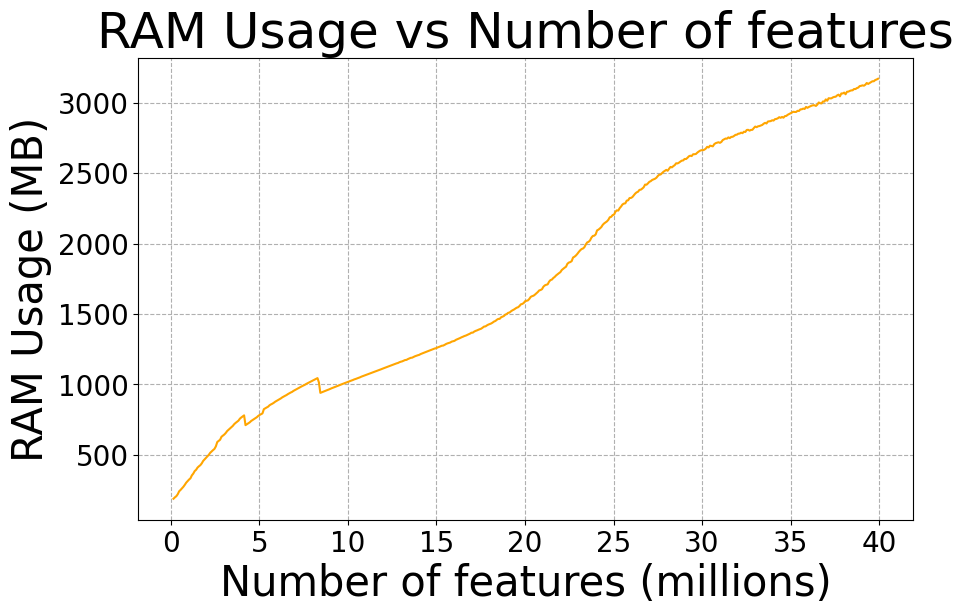

In [12]:
# Plot RAM usage vs size
plt.figure(figsize=(10, 6))
plt.plot(data['Number of features']/1_000_000, data['ram']/1024/1024, color='orange')
plt.title('RAM Usage vs Number of features', fontsize=36)
plt.xlabel('Number of features (millions)', fontsize=30)
plt.ylabel('RAM Usage (MB)', fontsize=30)
plt.tick_params(axis='both', which='major', labelsize=20)  # Increased font size for axis tick marks
#plt.xscale('log')
#plt.yscale('log')
plt.grid(True, which="both", ls="--")
plt.savefig('ram_vs_size.pdf', bbox_inches='tight')  # Ensure no truncation
plt.show()

In [13]:
len(data)


500

In [14]:
data

,Number of features,runtime,ram
0,159422,0.18,197697536
1,239133,0.21,208171008
2,318844,0.22,216469504
3,398555,0.23,231079936
4,478266,0.30,253001728
...,...,...,...
495,39616367,11.44,3304960000
496,39696078,11.45,3304910848
497,39775789,11.46,3314110464
498,39855500,11.80,3318046720


In [15]:
39_935_211

39935211